<a href="https://colab.research.google.com/github/madinasuraya/AppliedML/blob/main/WQD7012_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Attrition Analysis and Prediction in the Banking Sector using Machine Learning Classifiers**

**Course:** WQD7012 - MACHINE LEARNING FOR DATA SCIENCE<br>
**OCC:** 2<br>
**Semester:** Sem 2, 2025/2026 <br>
**Lecturer:** DR. FAIRUZ AMALINA NARUDIN <br>

**Group Members:**

1. RUZALDEEN BIN ZAINAL ABIDIN(17066349)
2. MADINA SURAYA(24071524)
3. REN LISHAN(25068790)
4. MU ANQI(24217565)
5. NORUL AINNA SYAHIRAH(25062229)

# 1. Data Preprocessing

In [ ]:
# Install dependencies
!pip install scikit-optimize imbalanced-learn shap

In [ ]:
############# DATA PREPROCESSING ###############
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

############# MODELLING ###############
import shap
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay
)

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/churn.csv')

In [ ]:
df = pd.read_csv('/content/churn.csv')

In [ ]:
# Check the dataset shape & info
print('Dataset Shape:')
print(df.shape)
print()
print('Dataset Info:')
print(df.info())

Dataset Shape:
(10000, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [ ]:
# Inspect dataset
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Check unique values per column
print('Uniqueness Info:')
print(df.nunique())
print()

# Identified that 'CustomerId', 'RowNumber' and 'Surname' are irrelevant features
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
print('Columns after drop:', df.columns.tolist())

Uniqueness Info:
RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

Columns after drop: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [ ]:
# Check for datatypes and missing values
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Data types:
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


# 2. Exploratory Data Analysis

## 2.1 Target Class Imbalance Check

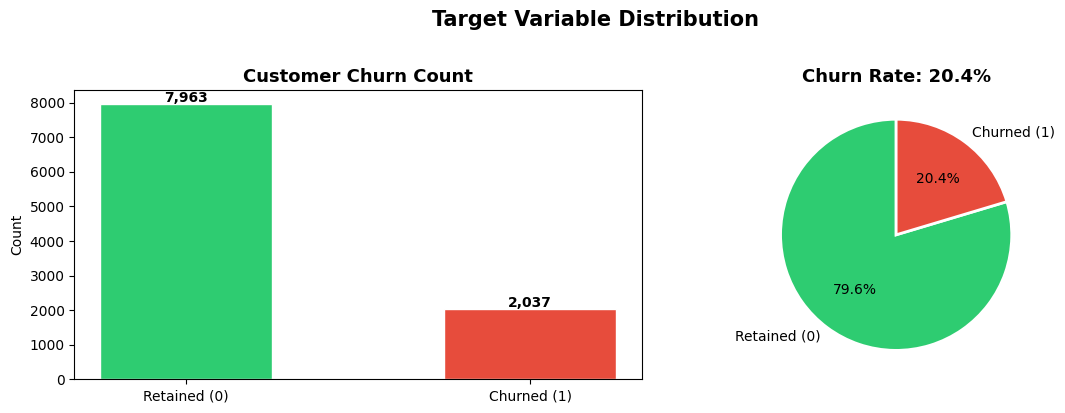

Churn rate: 20.37%. Class imbalance present (minority class = Churned)


In [ ]:
churn_counts = df['Exited'].value_counts()
churn_labels = ['Retained (0)', 'Churned (1)']
churn_rate   = df['Exited'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(churn_labels, churn_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Customer Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_labels,
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title(f'Churn Rate: {churn_rate:.1f}%', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Churn rate: {churn_rate:.2f}%. Class imbalance present (minority class = Churned)')

We found that the average churn rate for the customers is **20.4%**. A huge class imabalance was also observed with the ratio of **3.9**

## 2.2 Churn Status per Numerical Features

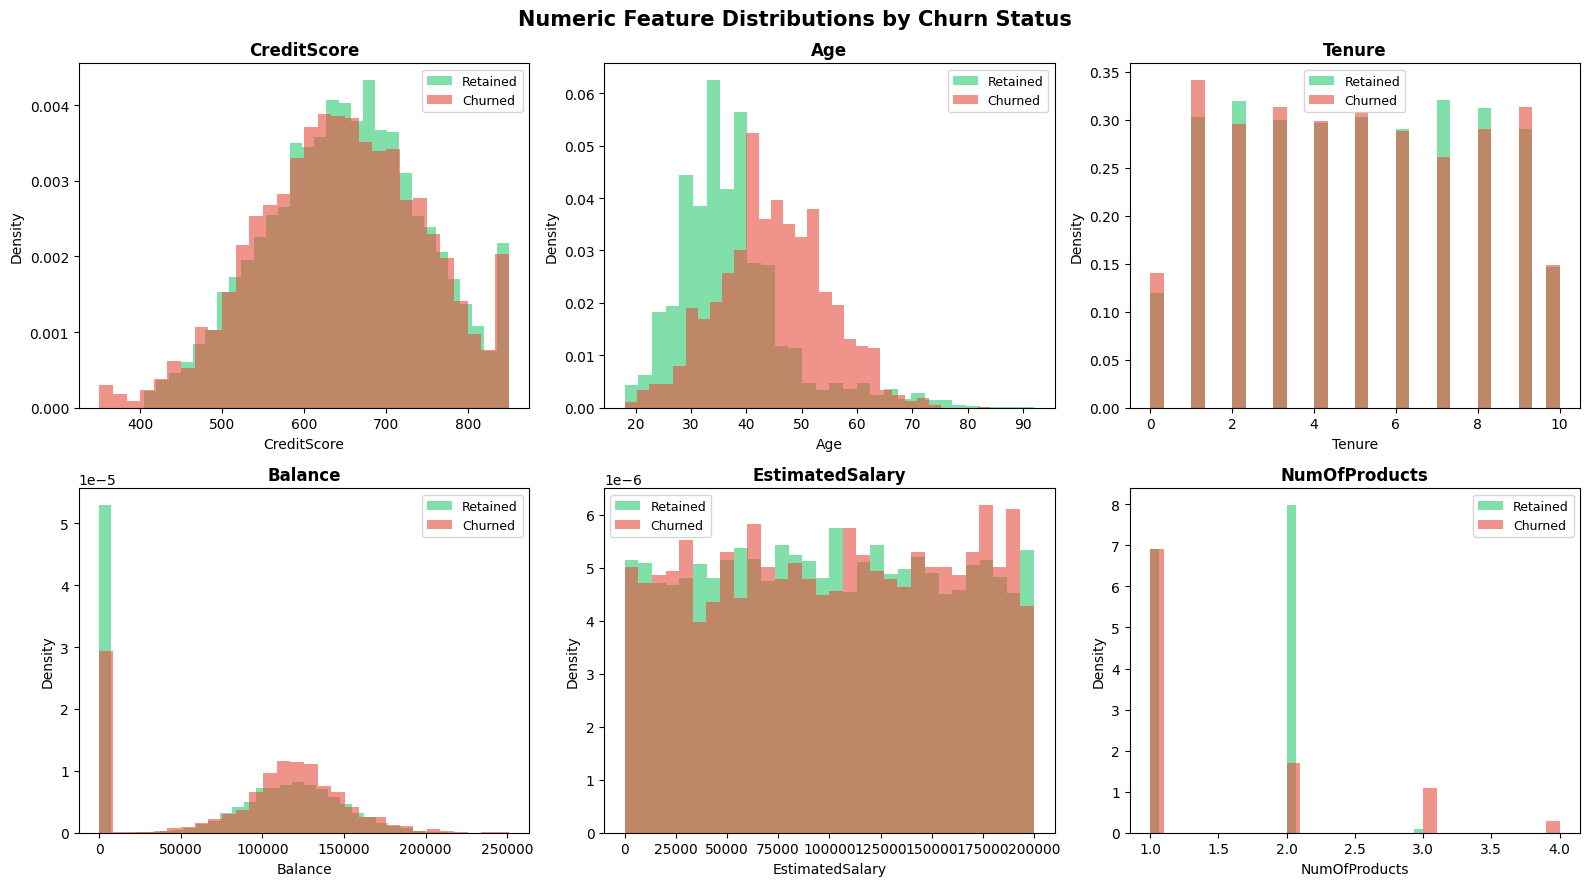

In [ ]:
# Continous feature distributions split by churn
num_feats = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, num_feats):
    for exited, label, color in [(0, 'Retained', '#2ecc71'), (1, 'Churned', '#e74c3c')]:
        data = df[df['Exited'] == exited][feat]
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

We can see most of the data is overlapped over each other except for significant difference in **Age** and **NumOfProducts** where older customers tend to churn compared to newer customers and the ideal number of products for retention for each customer is 2.

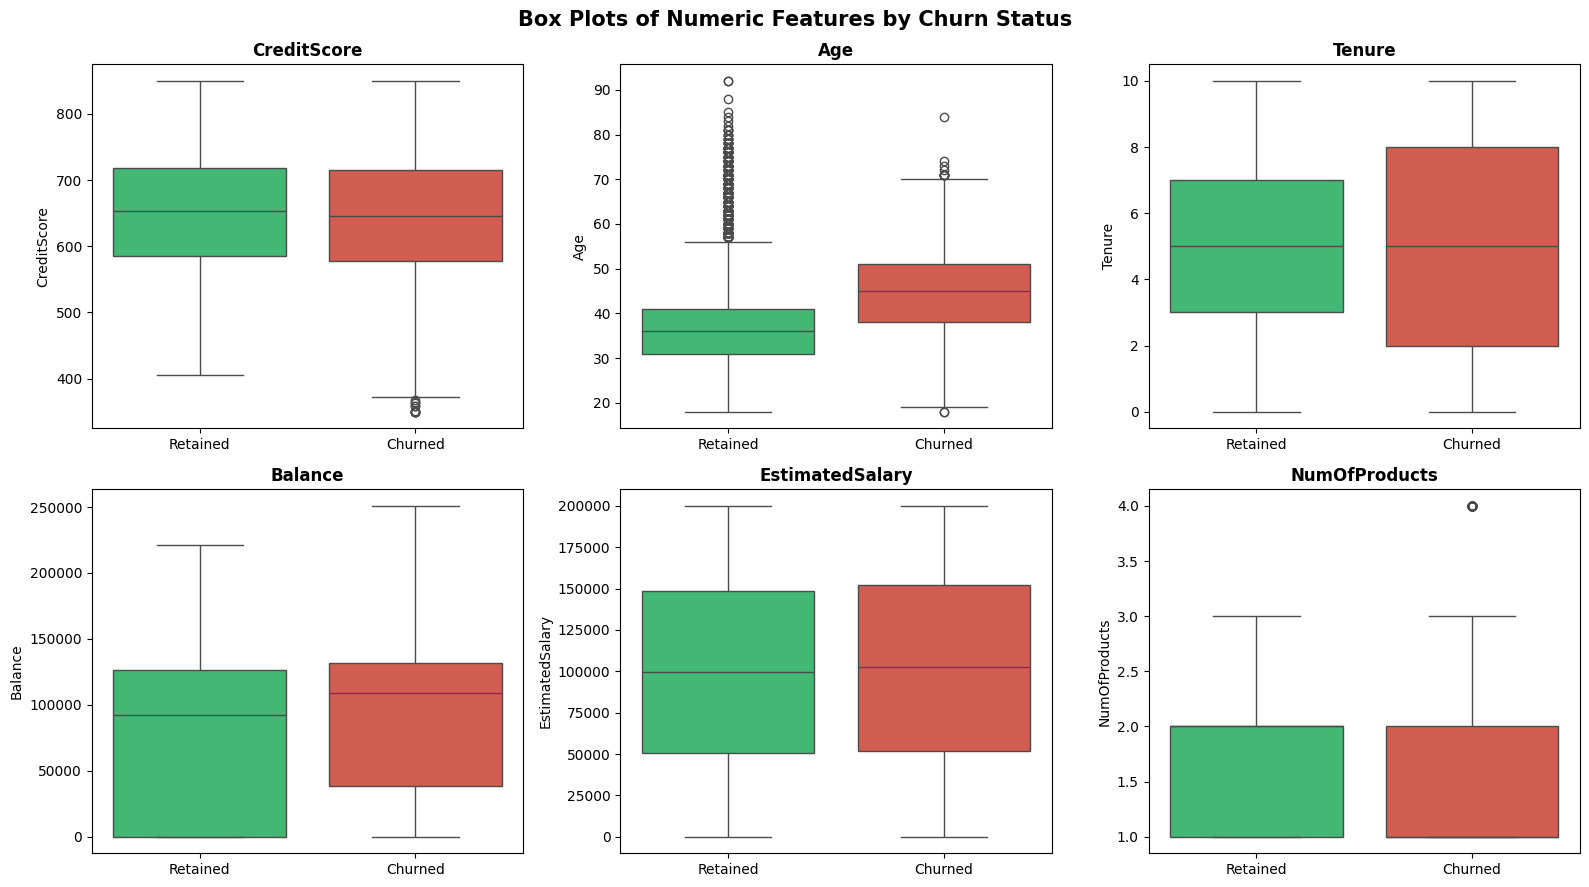

In [ ]:
# Box plots for numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, num_feats):
    sns.boxplot(data=df, x='Exited', y=feat, palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Box Plots of Numeric Features by Churn Status', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Similar observation can be seen in the boxplot where as per above observation. Except here we observed that spread for **Balance** and **Tenure** has slight differences in the customers. Somehow for **Balance**, lower values tend to retain more than the churn customers. For **Tenure**, more customers tend to stay if they are with the bank for more than 3 years.

## 2.3 Churn Status per Categorical Features

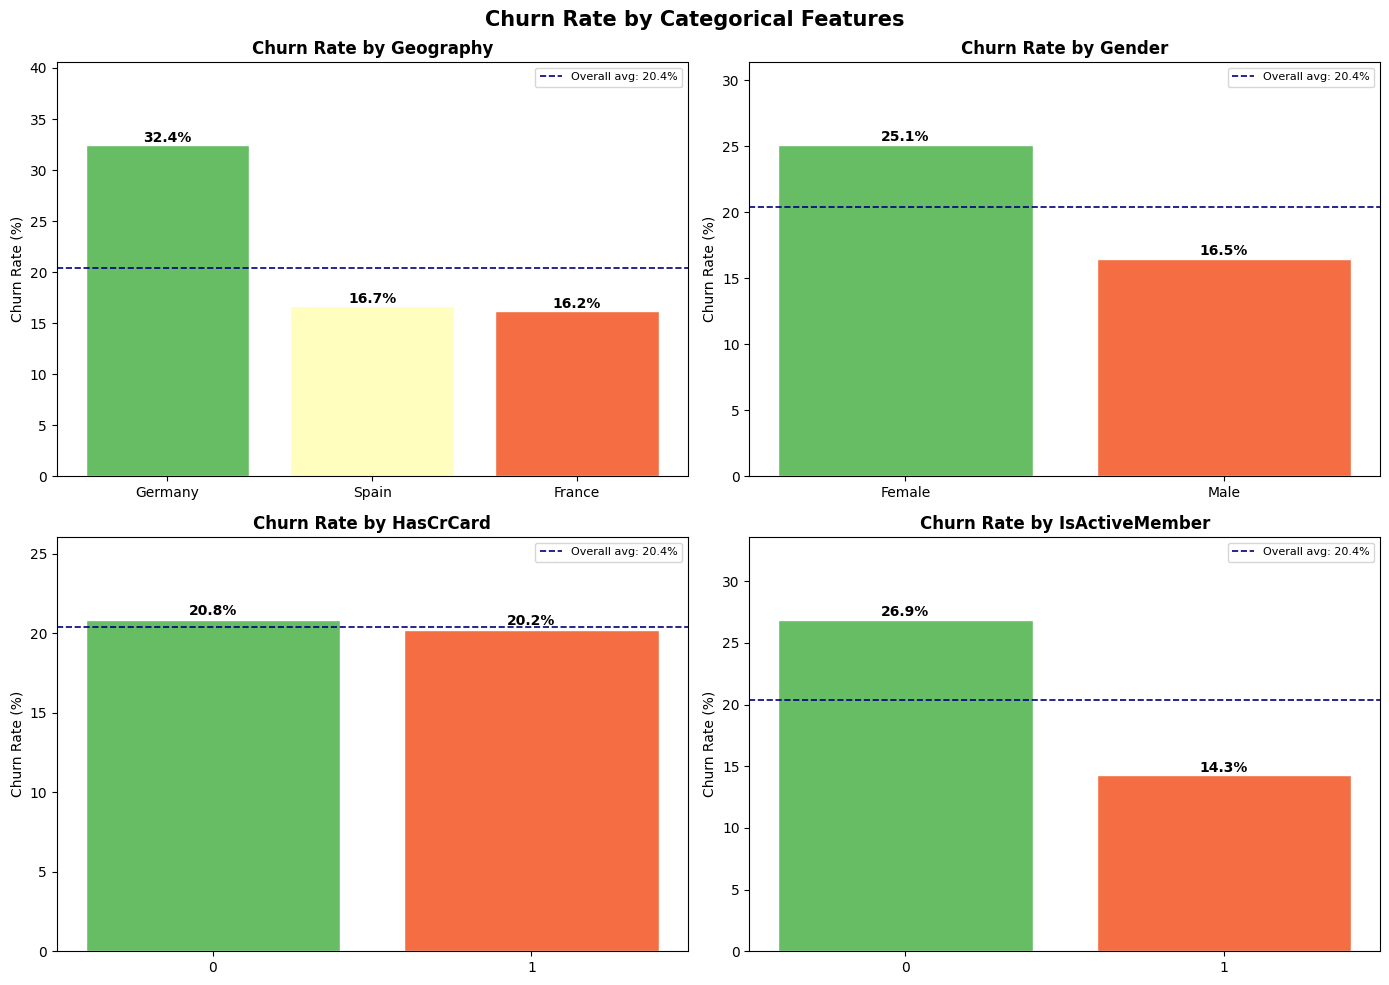

In [ ]:
# Bar plot with average churn rate
cat_feats = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, cat_feats):
    ct = df.groupby(feat)['Exited'].mean().sort_values(ascending=False) * 100
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ct)))
    bars = ax.bar(ct.index.astype(str), ct.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, ct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Churn Rate by {feat}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, ct.max() * 1.25)
    ax.axhline(df['Exited'].mean()*100, color='navy', linestyle='--', linewidth=1.2,
               label=f'Overall avg: {df["Exited"].mean()*100:.1f}%')
    ax.legend(fontsize=8)

plt.suptitle('Churn Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

For categorical features, Germany tends to have the highest churn rate in the **Geography** data and Female customers have a higher churn rate than Male in the **Gender** category. Inactive members tend to churn more matches the data from the **IsActiveMember** column.

## 2.4 Correlation Analysis

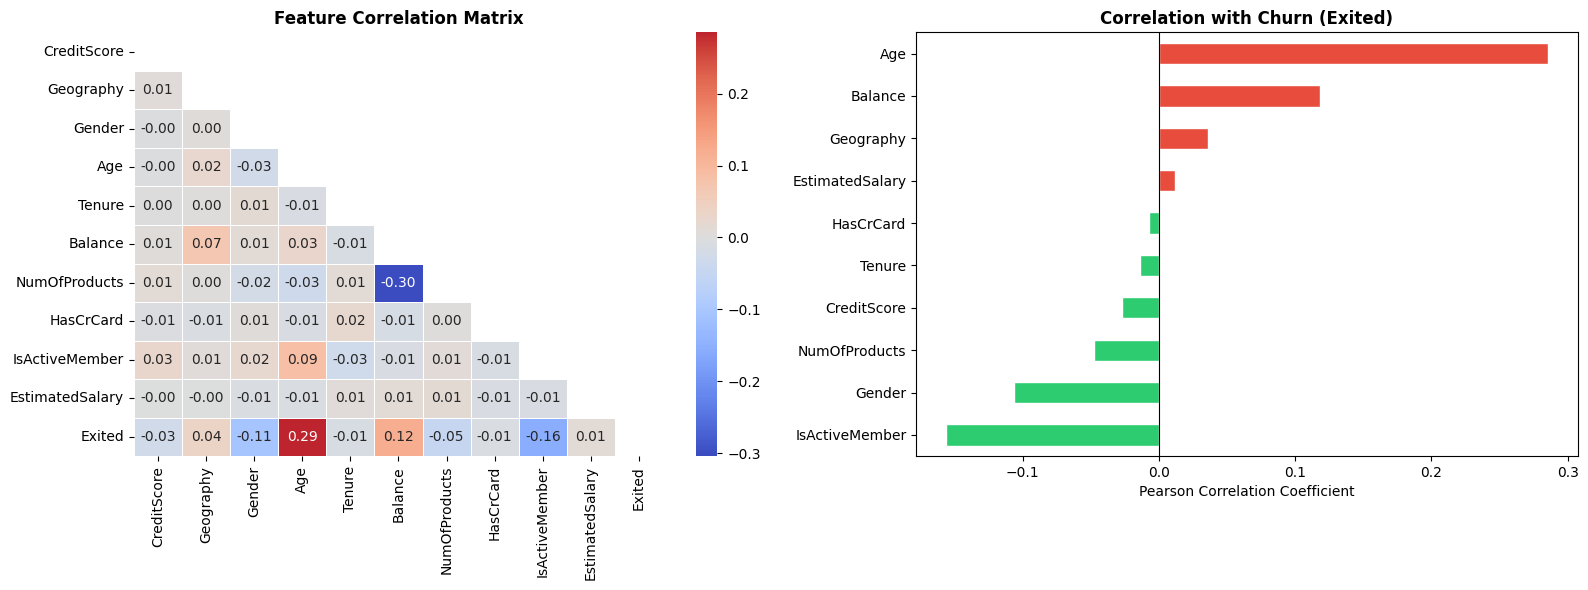

Top positive correlates (risk factors):
Age                0.285323
Balance            0.118533
Geography          0.035943
EstimatedSalary    0.012097
Name: Exited, dtype: float64

Top negative correlates (protective factors):
IsActiveMember   -0.156128
Gender           -0.106512
NumOfProducts    -0.047820
CreditScore      -0.027094
Tenure           -0.014001
HasCrCard        -0.007138
Name: Exited, dtype: float64


In [ ]:
# Label-encode categoricals temporarily for correlation
df_enc = df.copy()
df_enc['Gender']    = LabelEncoder().fit_transform(df_enc['Gender'])
df_enc['Geography'] = LabelEncoder().fit_transform(df_enc['Geography'])

corr = df_enc.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# Correlation with target
target_corr = corr['Exited'].drop('Exited').sort_values()
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr]
target_corr.plot(kind='barh', color=colors, ax=axes[1], edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Churn (Exited)', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')

plt.tight_layout()
plt.show()

print('Top positive correlates (risk factors):')
print(target_corr[target_corr > 0].sort_values(ascending=False))
print('\nTop negative correlates (protective factors):')
print(target_corr[target_corr < 0].sort_values())

Correlation analysis showed that **Age** had the strongest positive correlation with customer churn, followed by **Balance**. In contrast, **IsActiveMember** was negatively correlated with churn, suggesting that active members were less likely to leave

## 2.5 Demographics Analysis

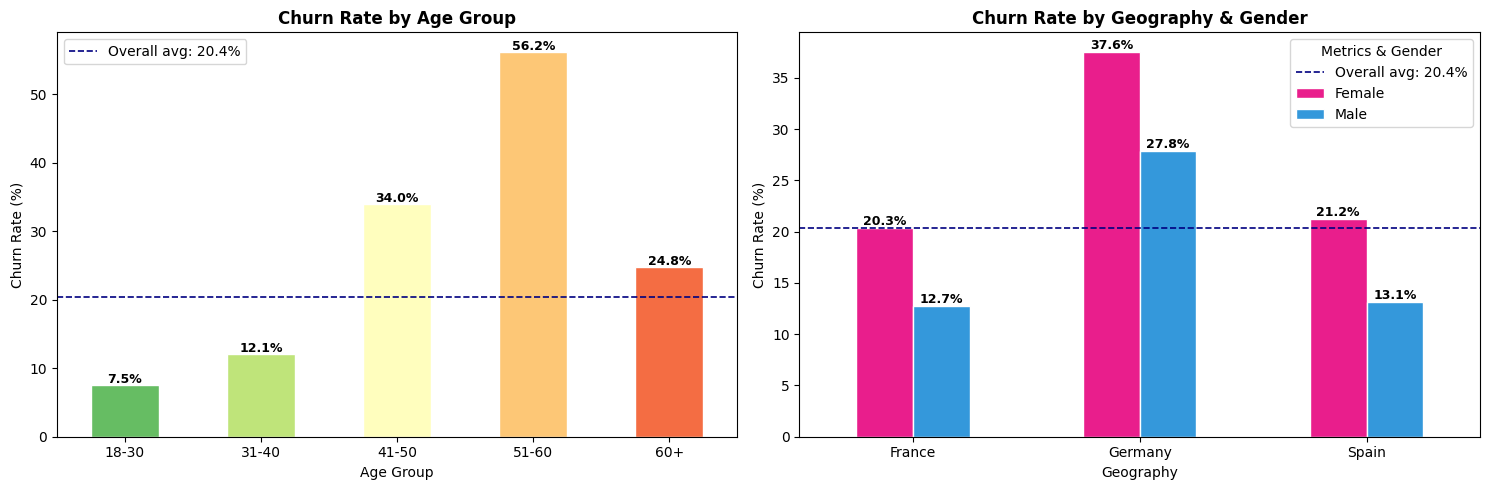

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age bins vs churn rate
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 40, 50, 60, 100],
                        labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
age_churn.plot(kind='bar', color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(age_churn))),
               ax=axes[0], edgecolor='white', rot=0, legend=False)
axes[0].set_title('Churn Rate by Age Group', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Age Group')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='semibold')

avg_line = axes[0].axhline(df['Exited'].mean()*100, color='navy', linestyle='--', linewidth=1.2,
                           label=f'Overall avg: {df["Exited"].mean()*100:.1f}%')
axes[0].legend(handles=[avg_line], loc='upper left')


# Geography & Gender churn rate
geo_gender = df.groupby(['Geography', 'Gender'])['Exited'].mean().unstack() * 100
geo_gender.plot(kind='bar', ax=axes[1], color=['#e91e8c', '#3498db'], edgecolor='white', rot=0)
axes[1].set_title('Churn Rate by Geography & Gender', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Geography')
# axes[1].legend(title='Gender')

for bar in axes[1].patches:
    height = bar.get_height()
    if height > 0:
      axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.3,
                    f'{height:.1f}%', ha='center', fontsize=9, fontweight='semibold')

axes[1].axhline(df['Exited'].mean()*100, color='navy', linestyle='--', linewidth=1.2,
               label=f'Overall avg: {df["Exited"].mean()*100:.1f}%')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=labels, title='Metrics & Gender', loc='upper right')

plt.tight_layout()
plt.show()
df.drop(columns=['AgeGroup'], inplace=True)

 Customers aged 51–60 recorded the highest churn rate (56.2%), followed by customers aged 41–50 (34.0%). In contrast, younger customers aged 18–30 exhibited the lowest churn rate (7.5%). Female customers tend to churn more than male across all three countries with their churn rate almost equal or more than the average churn rate.

# 3. Feature Engineering

In [ ]:
df_fe = df.copy()

# Encode categorical variable
# df_fe = pd.get_dummies(df_fe, columns=['Geography', 'Gender'], drop_first=True)

# Feature 1: Balance per Product
# Based on EDA: Balance is an important factor
df_fe['BalancePerProduct'] = df_fe['Balance'] / (df_fe['NumOfProducts'] + 1)

# Feature 2: Active Balance
# Based on EDA: Active members have lower churn
df_fe['ActiveBalance'] = df_fe['Balance'] * df_fe['IsActiveMember']

# Feature 3: Age Group
# Based on EDA: Age strongly correlates with churn
df_fe['AgeGroup'] = pd.cut(df_fe['Age'],
                          bins=[17, 30, 40, 50, 60, 100],
                          labels=[0,1,2,3,4])
# Drop 'Age' since we have age group
df_fe.drop(columns=['Age'], inplace=True)
df_fe.head()

,CreditScore,Geography,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalancePerProduct,ActiveBalance,AgeGroup
0,619,France,Female,2,0.00,1,1,1,101348.88,1,0.00,0.00,2
1,608,Spain,Female,1,83807.86,1,0,1,112542.58,0,41903.93,83807.86,2
2,502,France,Female,8,159660.80,3,1,0,113931.57,1,39915.20,0.00,2
3,699,France,Female,1,0.00,2,0,0,93826.63,0,0.00,0.00,1
4,850,Spain,Female,2,125510.82,1,1,1,79084.10,0,62755.41,125510.82,2


In [ ]:
##train test split
from sklearn.model_selection import train_test_split

X = df_fe.drop('Exited', axis=1)
y = df_fe['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Save the raw copy for testing later
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = ['CreditScore', 'Tenure', 'Balance',
            'NumOfProducts', 'EstimatedSalary',
            'BalancePerProduct', 'ActiveBalance']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 4. Class imbalance Using SMOTENC (Synthetic Minority Over-sampling Technique for Nominal and Continuous features)

SMOTENC handles both continous and categorical data at the same time so it's best we use it for our case instead of the normal SMOTE that will cause issue for our categorical ordinal columns such as **AgeGroup**

In [ ]:
X_train.head()

,CreditScore,Geography,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalancePerProduct,ActiveBalance,AgeGroup
2151,1.058568,France,Male,0.684723,-1.226059,-0.910256,1,0,1.042084,-1.172376,-0.667998,3
8392,0.913626,Germany,Male,-0.696202,0.413288,-0.910256,1,0,-0.623556,0.610307,-0.667998,1
5006,1.079274,Germany,Female,-1.731895,0.601687,0.808830,1,1,0.308128,0.152661,1.269433,1
4117,-0.929207,France,Male,-0.005739,-1.226059,0.808830,1,0,-0.290199,-1.172376,-0.667998,1
7182,0.427035,Germany,Male,0.339492,0.548318,0.808830,0,1,0.135042,0.113971,1.212861,2


In [ ]:
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'AgeGroup']

In [ ]:
# Identify indices of categorical/ordinal columns
cat_indices = [X_train.columns.get_loc('Geography'), X_train.columns.get_loc('Gender'),
               X_train.columns.get_loc('HasCrCard'), X_train.columns.get_loc('IsActiveMember'),
               X_train.columns.get_loc('AgeGroup') ]

from imblearn.over_sampling import SMOTENC
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

# Convert back to DataFrame
X_train_resampled = pd.DataFrame(X_resampled, columns=X.columns)
y_train_resampled = pd.Series(y_resampled, name=y.name)

# Apply pd.get_dummies to the balanced data
X_train_resampled = pd.get_dummies(X_train_resampled, columns=['Geography','Gender'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Geography','Gender'], drop_first=True)

# Align the test columns to match the train columns perfectly
X_test = X_test.reindex(columns=X_train_resampled.columns, fill_value=0)

In [ ]:
##CLASS IMBALANCE HANDLING (SMOTE)
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)

# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Exited
0    6370
1    1630
Name: count, dtype: int64

After SMOTE:
Exited
1    6370
0    6370
Name: count, dtype: int64


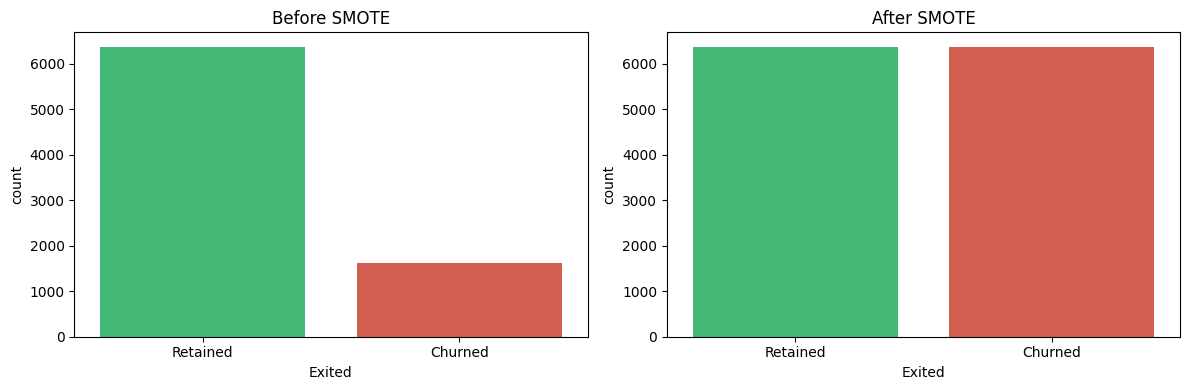

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['Retained', 'Churned'])

# After SMOTE
sns.countplot(x=y_train_resampled, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

#  5. Modeling & Evaluation

## 5.1 Data Preparation for Modeling

In [ ]:
# Check for any null issues after running SMOTENC
print(X_train_resampled.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


## 5.2 Logistic Regression Model

In [ ]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_resampled, y_train_resampled)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Classification Report")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, log_pred))

Logistic Regression Classification Report
Test Accuracy: 71.75%
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.69      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



## 5.3 Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Classification Report")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report
Test Accuracy: 82.85%
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1593
           1       0.57      0.63      0.60       407

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000



## 5.4 Support Vector Machine (SVM) Model

In [ ]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_resampled, y_train_resampled)

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, svm_pred)

print("SVM Classification Report")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, svm_pred))

SVM Classification Report
Test Accuracy: 79.10%
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1593
           1       0.49      0.72      0.58       407

    accuracy                           0.79      2000
   macro avg       0.71      0.77      0.72      2000
weighted avg       0.83      0.79      0.80      2000



## 5.5 Model Evaluation and Comparison

In [ ]:
# Summary

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, log_pred, log_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob),
    evaluate_model("SVM", y_test, svm_pred, svm_prob)
])

results.sort_values(by='F1-score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.8285,0.571111,0.631450,0.599767,0.843892
2,SVM,0.7910,0.490818,0.722359,0.584493,0.840603
0,Logistic Regression,0.7175,0.390278,0.690418,0.498669,0.773118


The results shows that Random Forest model achieved the best overall performance, with the highest Accuracy (82.85%), F1-score (59.98%), and ROC-AUC (84.39%), indicating a strong balance between correctly identifying churn and non-churn customers. SVM obtained the highest Recall (72.24%), meaning it was better at detecting churned customers, but its overall accuracy and F1-score were lower than Random Forest. Logistic Regression showed the weakest performance across most metrics. Therefore, **Random Forest was selected as the best model due to its superior overall predictive performance and balanced classification capability.**

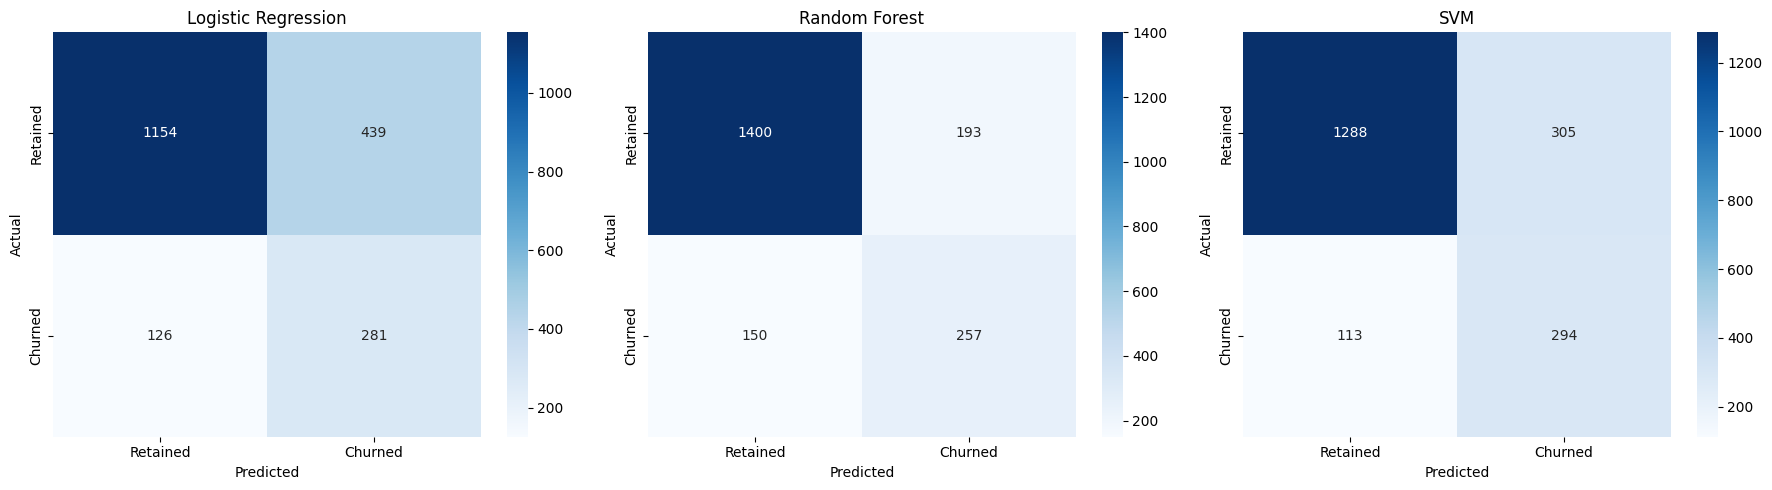

In [ ]:
# Confusion matrices

models_predictions = {
    'Logistic Regression': log_pred,
    'Random Forest': rf_pred,
    'SVM': svm_pred
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, prediction) in zip(axes, models_predictions.items()):

    cm = confusion_matrix(y_test, prediction)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Retained', 'Churned'],
        yticklabels=['Retained', 'Churned'],
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

The confusion matrix shows that Random Forest performed best in identifying retained customers, correctly classifying 1,400 non-churned customers while producing the fewest false positives. SVM was the most effective at detecting churned customers, correctly identifying 294 churn cases, which is important for customer retention strategies. Logistic Regression provided a more balanced performance but was generally less accurate than Random Forest and SVM. Therefore, **Random Forest may be preferred for overall prediction accuracy, while SVM may be more suitable when detecting potential churners is the primary objective.**

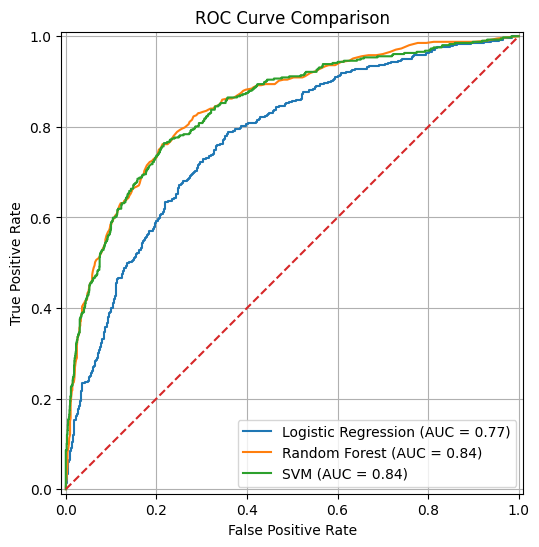

In [ ]:
# ROC curves comparison

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, log_prob, name='Logistic Regression', ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test, rf_prob, name='Random Forest', ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test, svm_prob, name='SVM', ax=plt.gca()
)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

The ROC curves show that all models perform better than random guessing, as their curves lie well above the diagonal baseline. Logistic Regression achieved an AUC of 0.77, indicating good discrimination between churned and retained customers. Both Random Forest and SVM achieved a higher AUC of 0.84, demonstrating stronger predictive capability and a better balance between detecting churned customers and minimizing false alarms. Since **Random Forest and SVM have the highest AUC values, they are the most effective models for distinguishing between customers who are likely to churn and those who are likely to remain.**

In [ ]:
# Final best model selection

best_model = results.loc[results['F1-score'].idxmax()]

print("Best Model Based on F1-score:")
print(best_model)

Best Model Based on F1-score:
Model        Random Forest
Accuracy            0.8285
Precision         0.571111
Recall             0.63145
F1-score          0.599767
ROC-AUC           0.843892
Name: 1, dtype: object


Based on the evaluation results, Random Forest was selected as the best model because it achieved the highest F1-score (0.600), indicating the best balance between precision and recall. It also achieved the highest ROC-AUC score (0.844), demonstrating a stronger ability to distinguish between churned and retained customers compared to the other models.  Therefore, **Random Forest was selected as the final predictive model.**

## 5.6 Hyperparameter Tuning on the Best Model

Since Random Forest chosen as the best model, to further improve the model capabilities hyperparameter tuning must be done . The selection of parameters to be tuned are as follows with the description and rationale included (taken from: [Scikit-learn : RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)).



1. `rf__n_estimators` (100-600): Controls how many decision trees are in the forest. **More trees reduce variance and stabilise predictions**, which matters for an imbalanced dataset because individual trees trained on bootstrapped samples may rarely see enough minority-class examples.

2. `rf__max_depth` (3-30): Controls how deep each tree can grow.** Shallow trees underfit** and miss minority-class patterns while **unconstrained trees overfit** to noise in the majority class, which is the dominant risk in imbalanced settings.

3. `rf__min_samples_split` (2-20): The minimum number of samples required to split an internal node. A **low value** allows the tree to keep splitting down to very small node populations, which **helps detect rare minority-class clusters**. A **high value** forces the tree to only split on well-supported patterns, **acting as regularisation**.

4. `rf__min_samples_leaf` (1-15): The minimum number of samples that must exist at a leaf node. Unlike min_samples_split which governs whether a split happens, this governs where the split ends. Setting it to **low value** allows the tree to isolate single minority-class points at leaves, which **maximises recall** at the cost of potential overfitting. Raising it forces more conservative, generalised leaves.

5. `rf__max_features` ("sqrt", "log2", None): The number of features considered at each split. `sqrt` (the default) and `log2` introduce randomness that reduces correlation between trees and generally **improves generalisation**. `None` means all features are considered at every split, making each tree **more powerful individually but more correlated with one another**.

6. `rf__class_weight` ("balanced", "balanced_subsample", None): This parameter tells the model to **penalise misclassification of the minority class more heavily during training**. `balanced` computes class weights globally and applies them uniformly across all trees. `balanced_subsample` recomputes weights on each bootstrapped subsample. `None` means no weighting adjustment.

7. `rf__bootstrap` (True, False): `True` (the default) means each tree is trained on a bootstrapped sample of the training data, **introducing diversity across trees**. `False` means every tree sees the full training set, which removes sampling randomness and can make **individual trees stronger at the cost of ensemble diversity**.





For SMOTENC in the tuning pipeline, single parameter is chosen which is (taken from [Imbalanced-learn : SMOTENC](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html)) :

1.   `smote__k_neighbors` (3-10): This is the number of nearest neighbours SMOTE uses when generating each synthetic minority sample. It determines **how localised or spread-out the synthetic points are**. A **low value** generates tight, **localised synthetic clusters close to existing minority points**, which is safer but may not improve minority coverage much. A **higher value** generates more interpolated, **spread-out synthetic samples** that better fill the minority-class decision boundary, but can **introduce noisy or borderline synthetic points** if minority clusters are heterogeneous.




In [ ]:
# categorical columns for SMOTENC to identify
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'AgeGroup']

# one hot enconding columns for  preprocessing
ohe_cols = ['Geography', 'Gender']

# positional indices
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]
ohe_idx = [X_train.columns.get_loc(c) for c in ohe_cols]

SCORING = "f1"

# Step 1 SMOTENC: oversamples using the raw categorical columns.
# Step 2 OneHotEncoder: the pipeline-safe replacement for pd.get_dummies. Learns
#        categories per training fold, applies identical columns to the validation fold.
preprocess = ColumnTransformer(
    transformers=[("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ohe_idx)],
    remainder="passthrough",
)

pipe = ImbPipeline([
    ("smotenc", SMOTENC(categorical_features=cat_idx, random_state=42)),
    ("encode",  preprocess),
    ("rf",      RandomForestClassifier(random_state=42, n_jobs=-1)),
])

search_spaces = {
    "smotenc__k_neighbors":   Integer(3, 10),
    "rf__n_estimators":       Integer(100, 600),
    "rf__max_depth":          Integer(3, 30),
    "rf__min_samples_split":  Integer(2, 20),
    "rf__min_samples_leaf":   Integer(1, 15),
    "rf__max_features":       Categorical(["sqrt", "log2", None]),
    "rf__class_weight":       Categorical(["balanced", "balanced_subsample", None]),
    "rf__bootstrap":          Categorical([True, False]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bayes_search = BayesSearchCV(
    estimator=pipe,
    search_spaces=search_spaces,
    n_iter=50,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# Feed the raw (pre-resampling) training split. SMOTENC runs inside each fold.
bayes_search.fit(X_train_raw, y_train)

print("Best CV %s: %.4f" % (SCORING, bayes_search.best_score_))
for k, v in bayes_search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
# Visualize the model tuning pipeline
rf_finetuned_best_model

Pipeline(steps=[('smotenc',
                 SMOTENC(categorical_features=[1, 2, 7, 8, 12], k_neighbors=10,
                         random_state=42)),
                ('encode',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 2])])),
                ('rf',
                 RandomForestClassifier(bootstrap=False, max_depth=9,
                                        min_samples_leaf=3,
                                        min_samples_split=20, n_estimators=600,
                                        n_jobs=-1, random_state=42))])

**Hyperparameter tuning** was performed on the **Random Forest model** using **Bayesian Optimization (BayesSearchCV)** with **5-fold stratified cross-validation** and **F1-score** as the evaluation metric. A pipeline incorporating **SMOTENC**, **One-Hot Encoding**, and **Random Forest** was used to handle class imbalance and categorical features within each fold. The tuning process optimized key Random Forest parameters to improve predictive performance and identify the best model configuration for customer churn prediction.


In [ ]:
# Evaluate the tuned model on the held-out test set
rf_finetuned_best_model = bayes_search.best_estimator_
rf_finetuned_y_pred  = rf_finetuned_best_model.predict(X_test_raw)
rf_finetuned_y_prob = rf_finetuned_best_model.predict_proba(X_test_raw)[:, 1]

print("\nTest set performance:")
print(classification_report(y_test, rf_finetuned_y_pred, digits=4))
print("ROC-AUC: %.4f" % roc_auc_score(y_test, rf_finetuned_y_prob))


Test set performance:
              precision    recall  f1-score   support

           0     0.9213    0.8154    0.8651      1593
           1     0.5017    0.7273    0.5938       407

    accuracy                         0.7975      2000
   macro avg     0.7115    0.7714    0.7295      2000
weighted avg     0.8359    0.7975    0.8099      2000

ROC-AUC: 0.8547


In [ ]:
# Reevaluate where does the fine-tuned model sits among the others
results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, log_pred, log_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob),
    evaluate_model("SVM", y_test, svm_pred, svm_prob),
    evaluate_model("Random Forest (Fine-tuned)", y_test, rf_finetuned_y_pred, rf_finetuned_y_prob)
])

results.sort_values(by='F1-score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.8285,0.571111,0.631450,0.599767,0.843892
3,Random Forest (Fine-tuned),0.7975,0.501695,0.727273,0.593781,0.854721
2,SVM,0.7910,0.490818,0.722359,0.584493,0.840603
0,Logistic Regression,0.7175,0.390278,0.690418,0.498669,0.773118


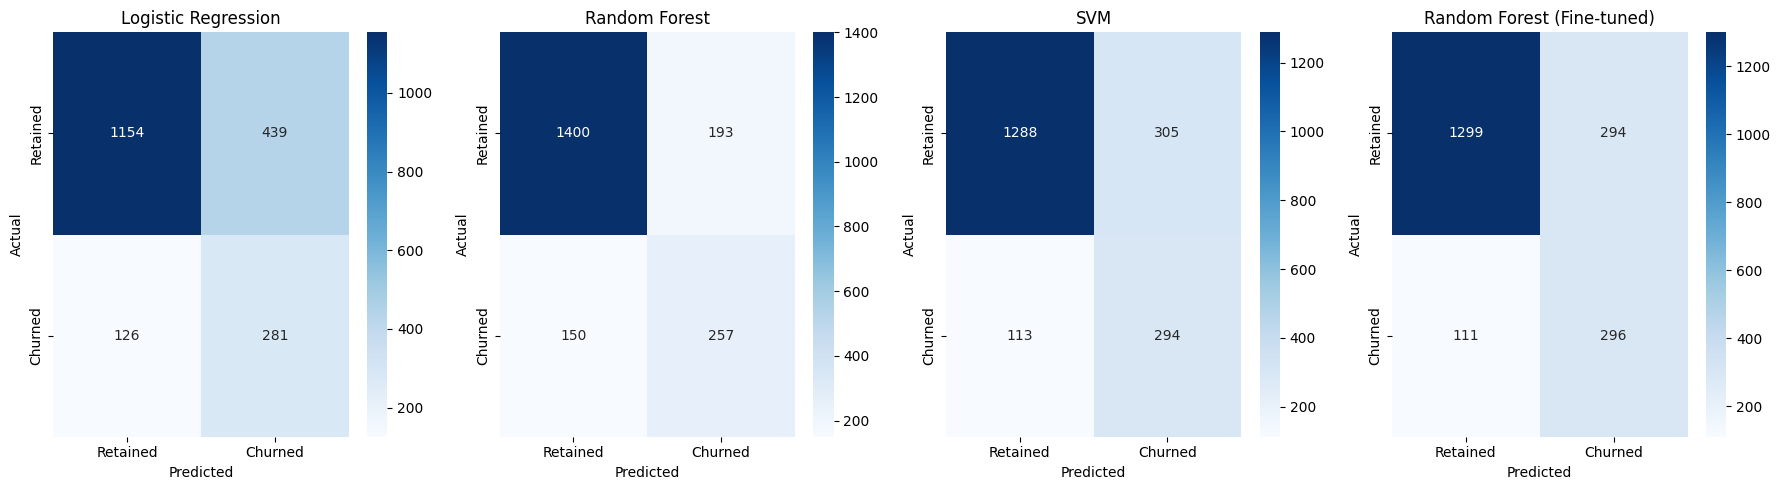

In [ ]:
# Confusion matrices

models_predictions = {
    'Logistic Regression': log_pred,
    'Random Forest': rf_pred,
    'SVM': svm_pred,
    'Random Forest (Fine-tuned)': rf_finetuned_y_pred
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (model_name, prediction) in zip(axes, models_predictions.items()):

    cm = confusion_matrix(y_test, prediction)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Retained', 'Churned'],
        yticklabels=['Retained', 'Churned'],
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

The confusion matrix shows that **Random Forest (Fine-tuned)** has the best capabilities in identifying actual churned customers over all models with **296** churned customers compared to the next best which is the SVM with **294**. It also has the **lowest** false positives rate over all the other models with only **111** customers. This means that the tuning works in helping our model to be more efficient in identifying churning customers.

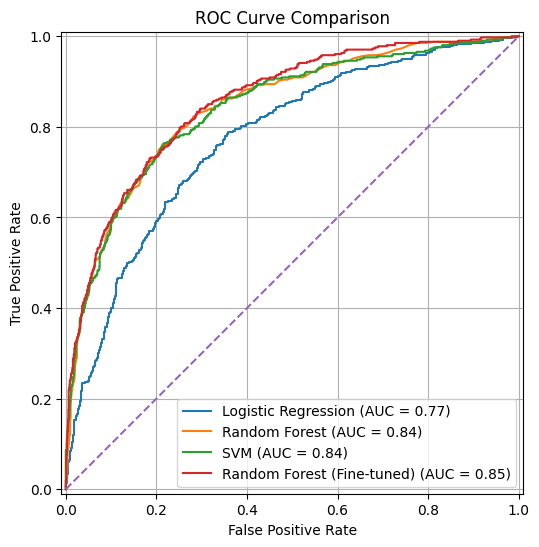

In [ ]:
# ROC curves comparison

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, log_prob, name='Logistic Regression', ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test, rf_prob, name='Random Forest', ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test, svm_prob, name='SVM', ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test, rf_finetuned_y_prob, name='Random Forest (Fine-tuned)', ax=plt.gca()
)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

The ROC curves show that the **fine-tuned Random Forest** achieved AUC of **0.85** demonstrating stronger predictive capability and a better balance between detecting churned customers compared to the **base Random Forest** and the **SVM**.

# 6. Explainable AI (XAI) & Feature Importance

## 6.1 Feature Importance

**Random Forest** was used for feature importance analysis due to its interpretability advantages.

In [ ]:
# Extract the model & features from the pipeline
rf_model_finetuned = rf_finetuned_best_model.named_steps["rf"]
feature_names = rf_finetuned_best_model.named_steps["encode"].get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names] # clean the prefix here

# Encode raw test data through the pipeline's own preprocessing (SMOTENC skipped at transform).
X_test_enc = rf_finetuned_best_model[:-1].transform(X_test_raw)
X_test_enc = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test_raw.index)

# Feature importance

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model_finetuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,AgeGroup,0.311984
8,NumOfProducts,0.247720
1,Geography_Germany,0.083276
7,Balance,0.066280
12,BalancePerProduct,0.063867
10,IsActiveMember,0.054407
13,ActiveBalance,0.037894
4,Gender_Male,0.024058
11,EstimatedSalary,0.022744
3,Gender_Female,0.021033


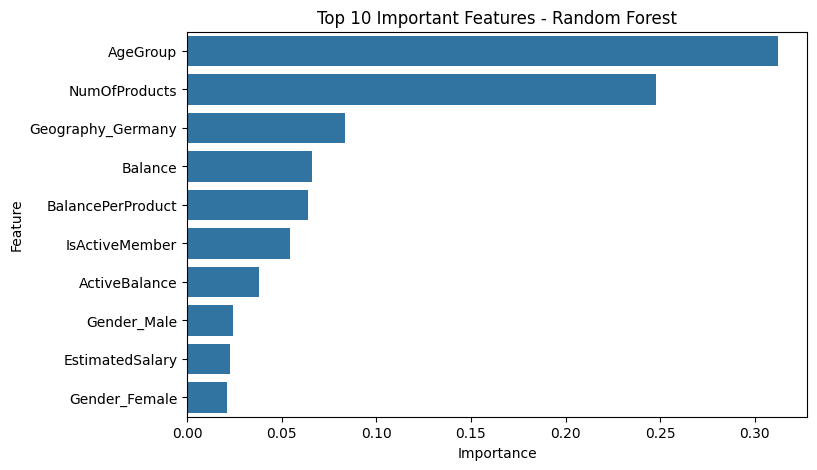

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The analysis identified **AgeGroup, NumOfProducts, Geography_Germany, and Balance** as the **most influential factors contributing to customer churn prediction.**

In [ ]:
# Install SHAP if required
# !pip install shap

## 6.2 Global Interpretability Using SHAP

To further improve model transparency, SHAP (SHapley Additive Explanations) was applied to explain the predictions generated by the selected Random Forest model. Unlike traditional feature importance methods, SHAP quantifies both the magnitude and direction of each feature's contribution to the model output.

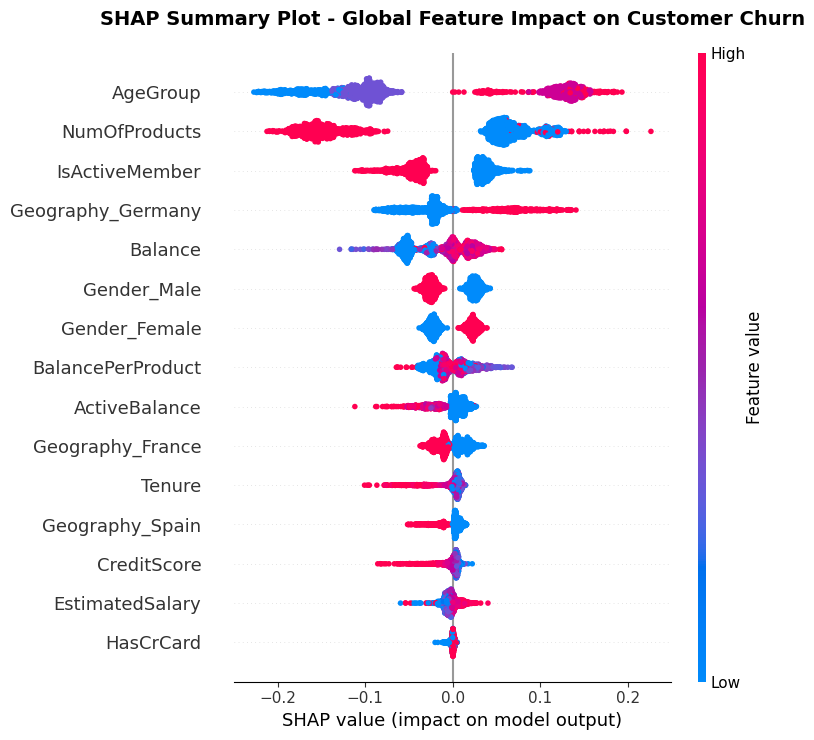

In [ ]:
# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model_finetuned)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_enc)

# Binary classification
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values[:, :, 1]

# SHAP Summary Plot
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values_churn,
    X_test_enc,
    feature_names=feature_names,
    show=False
)

plt.title(
    'SHAP Summary Plot - Global Feature Impact on Customer Churn',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

The SHAP summary plot provides a comprehensive view of both feature importance and the direction of feature impact on customer churn prediction. Consistent with the Random Forest feature importance analysis, Age, NumOfProducts, IsActiveMemeber, Geography_Germany, and Balance emerged as some of the most influential predictors.

Higher values of AgeGroup and Balance were generally associated with increased churn risk. Conversely, customers with stronger account activity and higher product adoption tended to exhibit lower churn probability.

As the Random Forest model was trained using the SMOTENC-balanced dataset, the SHAP explanations provide additional insight into how the model learned patterns associated with minority churn customers. Overall, SHAP enhances model transparency by explaining not only which features are important, but also how they influence churn behaviour.

## 6.3 Local Interpretability Using SHAP

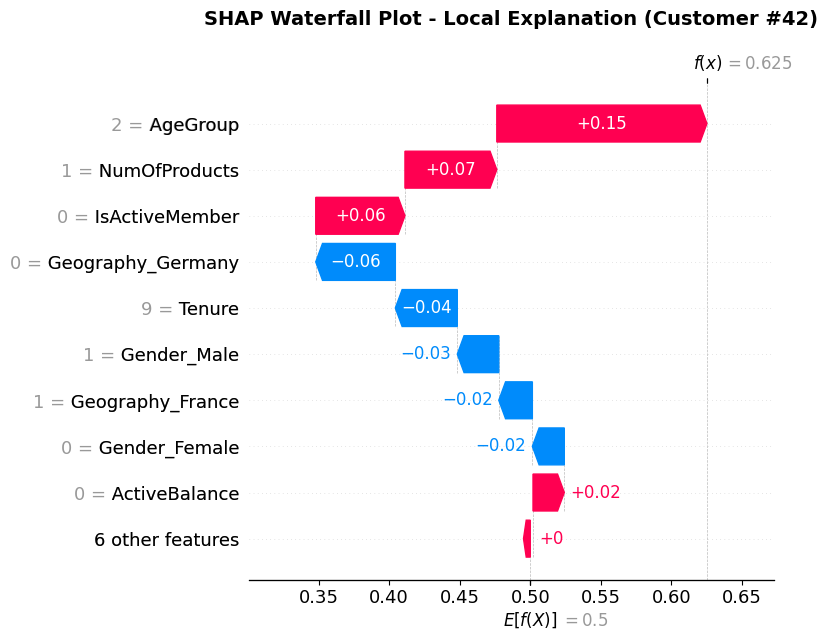

In [ ]:
# Select a sample customer
customer_index = 42

base_val = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

explanation = shap.Explanation(
    values=shap_values_churn[customer_index],
    base_values=base_val,
    data=X_test_enc.iloc[customer_index],
    feature_names=feature_names
)

plt.figure(figsize=(8,5))

shap.plots.waterfall(
    explanation,
    show=False
)

plt.title(
    f'SHAP Waterfall Plot - Local Explanation (Customer #{customer_index})',
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

The waterfall plot demonstrates local interpretability by explaining the prediction outcome for an individual customer. Starting from the baseline churn probability, each feature either increases or decreases the customer’s predicted churn risk.

For example, factors such as higher age, lower product ownership, or weaker account activity may contribute positively toward churn prediction, while stronger engagement indicators may reduce churn probability.

This form of local explanation is particularly valuable for business decision-making, as it enables banks to understand the specific reasons behind each customer’s predicted behaviour and supports the development of personalised retention strategies.

 ## 6.4 Limitations of Explainable AI

Although SHAP significantly improves model interpretability, several limitations should be acknowledged. The explanations generated remain dependent on the underlying Random Forest model and may differ when alternative machine learning algorithms are used.

In addition, SHAP computations can become computationally expensive when applied to larger datasets or more complex models. Therefore, while SHAP provides valuable insights into model behaviour, the explanations should be interpreted together with domain knowledge and business context.

## 6.5 Business Implications

The explainability analysis provides practical business value by helping financial institutions identify the key drivers of customer churn. By understanding which customer characteristics contribute most strongly to churn risk, banks can design more targeted retention strategies.

Consistent with the modelling results, customers characterised by higher age, lower product adoption, weaker account activity, and unfavourable account characteristics represent important retention targets. These customers may benefit from personalised engagement programmes, loyalty incentives, or proactive customer relationship management initiatives.

Explainable AI therefore supports not only predictive accuracy but also more informed, transparent, and actionable business decision-making.